# USRP Client API Tour

Alle Funktionen des `USRPClient` zum Ausprobieren:

| Funktion | Was sie tut |
|---|---|
| `send(signal)` | 1-D → SISO senden+empfangen, 2-D → MIMO |
| `send(signal, channel=1)` | SISO über Hardware-Kanal 1 |
| `send_siso(signal, channel=...)` | explizit SISO, Kanal waehlbar |
| `send_mimo(signal)` | explizit MIMO, Spalte i → Kanal i |
| `listen(n)` / `listen_siso(n, channel=...)` | nur empfangen (kein TX) |
| `listen_mimo(n)` | nur empfangen, alle Kanaele |

**Wichtig zum Interpretieren der Ergebnisse:**
- Die Guard-Zeiten vor/nach dem Signal werden pro Test **zufaellig** aus `[min, max]` gezogen (Server-Settings). Das Signal sitzt also nicht immer an derselben Stelle - Synchronisation ist Teil der Aufgabe!
- Der Traeger liegt im 2.4-GHz-ISM-Band: **WiFi-Bursts** sind im Zeitbereich oft staerker als das eigene Signal. Im Spektrum (FFT-Gain) ist der eigene Ton trotzdem klar sichtbar.
- Ein konstantes Signal (`np.ones`) landet bei 0 Hz, wo DC-Offset und LO-Leakage des Empfaengers sitzen - besser einen Ton mit Frequenz-Offset senden.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from usrp_benchmark import USRPClient

USRPClient.setup(
    host="129.132.24.210",
    port=80,
    token="gschwan-arxqpos5vxy642jlbstcmg2k",
)

print("Server OK:", USRPClient.check())
info = USRPClient.info()
fs = info["sample_rate_hz"]
print(f"Sample Rate: {fs/1e6:g} MHz")
print(f"Carrier:     {info['carrier_frequency_hz']/1e9:g} GHz")
print(f"MIMO:        {info['mimo_enabled']}, Kanaele: {[c['label'] for c in info['channels']]}")
print(f"Guards:      begin {info['begin_guard_min_sec']}..{info['begin_guard_max_sec']} s, "
      f"end {info['end_guard_min_sec']}..{info['end_guard_max_sec']} s (pro Test zufaellig)")

Server OK: True
Sample Rate: 1 MHz
Carrier:     2.44175 GHz
MIMO:        True, Kanaele: ['ch0', 'ch1']
Guards:      begin 0.1..0.1 s, end 0.1..0.1 s (pro Test zufaellig)


## Helfer: Testsignal + Plots

`plot_rx` zeigt pro Kanal die Leistungs-Envelope ueber der Zeit (log-Skala, da sieht man Signal-Burst, Guards und WiFi-Spikes) und das Spektrum.

In [3]:
def make_tone(n, f_offset_hz, amplitude=0.8):
    """Komplexer Ton bei `f_offset_hz` neben dem Traeger, n Samples."""
    t = np.arange(n) / fs
    return (amplitude * np.exp(2j * np.pi * f_offset_hz * t)).astype(np.complex64)


def plot_rx(rx, title="", flim_khz=None):
    """Envelope (dB) + Spektrum, funktioniert fuer 1-D (SISO) und 2-D (MIMO)."""
    rx = np.asarray(rx)
    chans = [rx] if rx.ndim == 1 else [rx[:, i] for i in range(rx.shape[1])]
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.2))
    for i, x in enumerate(chans):
        lbl = f"ch{i}" if len(chans) > 1 else None
        k = max(int(fs / 1000), 1)                     # 1-ms-Glaettung
        env = np.convolve(np.abs(x) ** 2, np.ones(k) / k, mode="same")
        ax[0].plot(np.arange(len(x)) / fs * 1e3, 10 * np.log10(env + 1e-15), lw=0.8, label=lbl)
        w = np.hanning(len(x))
        spec = np.abs(np.fft.fftshift(np.fft.fft(x * w)))
        freqs = np.fft.fftshift(np.fft.fftfreq(len(x), d=1 / fs))
        s_db = 20 * np.log10(spec + 1e-15)
        ax[1].plot(freqs / 1e3, s_db - s_db.max(), lw=0.8, label=lbl)
    ax[0].set_title(f"{title} - Envelope"); ax[0].set_xlabel("Zeit [ms]"); ax[0].set_ylabel("Leistung [dB]")
    ax[1].set_title("Spektrum"); ax[1].set_xlabel("Frequenz-Offset [kHz]"); ax[1].set_ylabel("Magnitude [dB]")
    ax[1].set_ylim(-90, 5)
    if flim_khz:
        ax[1].set_xlim(-flim_khz, flim_khz)
    if len(chans) > 1:
        ax[0].legend(); ax[1].legend()
    fig.tight_layout(); plt.show()


N = 100_000                        # 100 ms bei 1 MHz
tx_tone = make_tone(N, 100e3)      # Ton bei +100 kHz
print(f"Testsignal: {N} Samples = {N/fs*1e3:.0f} ms, Ton bei +100 kHz")

Testsignal: 100000 Samples = 100 ms, Ton bei +100 kHz


## 1. `send()` - SISO, wie bisher

1-D-Array rein, 1-D-Array raus. Ohne `channel=` laeuft es ueber Kanal 0 (byte-identisch zum alten Verhalten).

False
[upload] Sent 800,000 bytes
[info] USRP | Carrier: 2442 MHz | BW: 0 MHz | Rate: 1 MSps
[queued] Task a6d31688... - next in line
[done] Processing complete                
[download] Receiving result...
[download] 2,400,000 bytes received - 300,000 samples
Empfangen: 300000 Samples = 300.0 ms


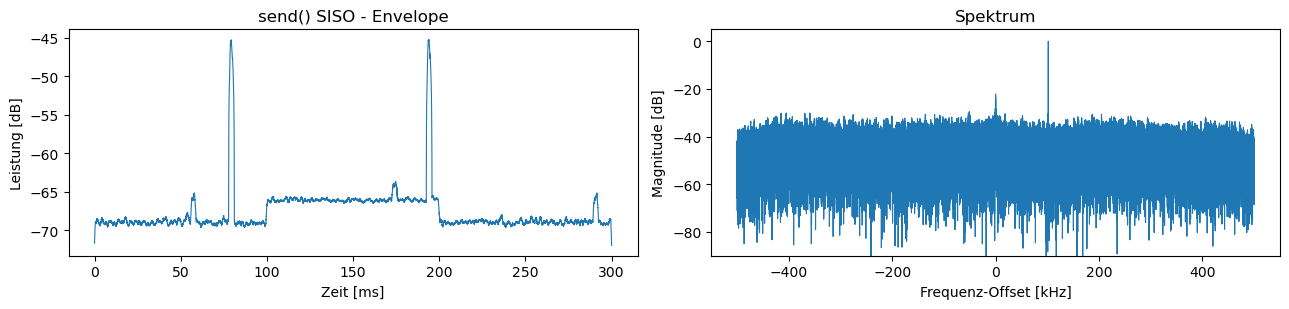

In [19]:
from usrp_benchmark import USRPClient
print(hasattr(USRPClient, "listen"))   # True = neue Version
rx = USRPClient.send(tx_tone, verbose=True)

print(f"Empfangen: {len(rx)} Samples = {len(rx)/fs*1e3:.1f} ms")
plot_rx(rx,  "send() SISO")

## 2. `send_siso()` mit Kanalwahl

`channel=` waehlt den Hardware-Kanal aus dem Inventory (Antenne + Gains des Kanals werden verwendet). `send(tx, channel=1)` geht genauso.

In [16]:
rx0 = USRPClient.send_siso(tx_tone, channel=0)

plot_rx(rx0, "send_siso(channel=0)")

AttributeError: type object 'USRPClient' has no attribute 'send_siso'

In [ ]:
rx1 = USRPClient.send_siso(tx_tone, channel=1)
plot_rx(rx1, "send_siso(channel=1)")

## 3. `send_mimo()` - beide Kanaele gleichzeitig

Shape `(n_samples, n_channels)`, Spalte i wird auf Kanal i gesendet. Hier: Kanal 0 sendet +100 kHz, Kanal 1 sendet -150 kHz - im RX-Spektrum sieht man beide Toene und das Uebersprechen zwischen den Kanaelen.

In [ ]:
tx_mimo = np.stack([make_tone(N, 100e3), make_tone(N, -150e3)], axis=1)
print("TX shape:", tx_mimo.shape)

rx_mimo = USRPClient.send_mimo(tx_mimo)
print("RX shape:", rx_mimo.shape)
plot_rx(rx_mimo, "send_mimo() 2 Kanaele")

## 4. `listen()` - nur empfangen, ohne zu senden

Kein TX, keine Guards - einfach `n` Samples vom Empfaenger. Praktisch um den Kanal/Stoerer (WiFi!) anzuschauen oder den Rauschboden zu messen.

In [ ]:
rx = USRPClient.listen_siso(200_000, channel=0, verbose=True)
print(f"Empfangen: {len(rx)} Samples = {len(rx)/fs*1e3:.0f} ms")
plot_rx(rx, "listen_siso(200k, channel=0)")

In [ ]:
rx = USRPClient.listen_siso(200_000, channel=1)
plot_rx(rx, "listen_siso(200k, channel=1)")

In [ ]:
rx = USRPClient.listen_mimo(200_000)     # channels default = alle (mimo_max_channels)
print("RX shape:", rx.shape)
plot_rx(rx, "listen_mimo(200k)")

## 5. Bonus: Signal im Zufalls-Guard finden (Mini-Synchronisation)

Da die Guards zufaellig sind, weiss man nicht, wo das Signal anfaengt. So findet man den eigenen Ton robust (schmalbandig gefiltert, damit WiFi nicht stoert):

In [ ]:
rx = USRPClient.send_siso(tx_tone, channel=0)

# 1) exakte Tonfrequenz im Spektrum suchen (CFO ~ wenige kHz)
w = np.hanning(len(rx))
spec = np.abs(np.fft.fftshift(np.fft.fft(rx * w)))
freqs = np.fft.fftshift(np.fft.fftfreq(len(rx), d=1/fs))
m = np.abs(freqs - 100e3) < 10e3
f0 = freqs[m][np.argmax(spec[m])]

# 2) runtermischen + Tiefpass -> Envelope nur unseres Tons
bb = rx * np.exp(-2j*np.pi*f0*np.arange(len(rx))/fs)
k = int(fs/1000)
env = np.abs(np.convolve(bb, np.ones(k)/k, mode="same"))**2
start = int(np.argmax(env > 0.25*env.max()))

print(f"Ton gefunden bei {f0/1e3:.2f} kHz (CFO: {(f0-100e3):.0f} Hz)")
print(f"Signalstart: Sample {start} = {start/fs*1e3:.1f} ms  (= gezogener begin-Guard)")

plt.figure(figsize=(13, 3))
plt.plot(np.arange(len(rx))/fs*1e3, 10*np.log10(env + 1e-15), lw=0.8)
plt.axvline(start/fs*1e3, color="red", ls="--", label=f"Start {start/fs*1e3:.1f} ms")
plt.xlabel("Zeit [ms]"); plt.ylabel("Ton-Leistung [dB]"); plt.legend(); plt.tight_layout(); plt.show()

## 6. Dasselbe per CLI / Binary

Die Client-Binaries (`usrp-client-linux/macos/windows`, GitHub-Release) koennen das auch:

```bash
usrp-client -s 129.132.24.210:80 -t <TOKEN> -i signal.f32 -o out.f32        # senden wie bisher
usrp-client -s 129.132.24.210:80 -t <TOKEN> -i signal.f32 -c 1              # SISO ueber Kanal 1
usrp-client -s 129.132.24.210:80 -t <TOKEN> --listen 100000 -o rx.f32       # nur empfangen
usrp-client -s 129.132.24.210:80 -t <TOKEN> --listen 100000 --channels 2 -o rx.f32   # MIMO-Listen
```

`.f32`-Dateien sind float32 interleaved I/Q; MIMO-Dateien haben einen 16-Byte-Header (siehe `usrp_testbed_library/mimo_format.py`).